# PARKINSON'S DISEASE DETECTION - EFFICIENTNETB0
## Colab notebook for a single transfer learning model

**Dataset:** https://www.kaggle.com/datasets/kmader/parkinsons-drawings  
**Model:** EfficientNetB0 with ImageNet weights  
**Goal:** Add one strong transfer learning baseline while keeping the original external test set untouched.  
**Expected folder structure:** `/content/drive/MyDrive/Parkinsons/drawings/spiral/{training,testing}/{healthy,parkinson}`

---
## STEP 1: SETUP AND MOUNT GOOGLE DRIVE

In [ ]:
# Import libraries
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('Libraries imported!')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

Libraries imported!
TensorFlow version: 2.19.0
GPU available: []


In [ ]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted!')
except Exception as e:
    print('Google Drive mount skipped:', e)

Mounted at /content/drive
Google Drive mounted!


In [ ]:
class HistoryContainer:
    def __init__(self, history):
        self.history = history


def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(list(values))
    return HistoryContainer(merged)


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1].set_title(f'{model_name} - AUC', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    axes[2].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[2].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[2].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Loss', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(SAVE_PATH, f'{model_name}_training_history.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Training history saved: {plot_path}')


def safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return float('nan')


def find_best_threshold(model, val_generator):
    val_generator.reset()
    y_score = model.predict(val_generator, verbose=0).ravel()
    y_true = val_generator.classes

    threshold_grid = np.linspace(0.25, 0.75, 51)
    best_threshold = 0.5
    best_acc = -1.0
    best_balanced_acc = -1.0
    best_f1 = -1.0

    for threshold in threshold_grid:
        y_pred = (y_score >= threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)
        balanced_acc = balanced_accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if (acc > best_acc) or (acc == best_acc and balanced_acc > best_balanced_acc) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 > best_f1) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 == best_f1 and abs(threshold - 0.5) < abs(best_threshold - 0.5)):
            best_threshold = float(threshold)
            best_acc = float(acc)
            best_balanced_acc = float(balanced_acc)
            best_f1 = float(f1)

    print(f'Best validation threshold: {best_threshold:.2f}')
    print(f'Validation accuracy at best threshold: {best_acc:.4f}')
    print(f'Validation balanced accuracy at best threshold: {best_balanced_acc:.4f}')
    print(f'Validation F1 at best threshold: {best_f1:.4f}')

    return best_threshold


def evaluate_model(model, generator, model_name, threshold=0.5):
    generator.reset()

    y_score = model.predict(generator, verbose=0).ravel()
    y_pred = (y_score >= threshold).astype(int)
    y_true = generator.classes

    eval_values = model.evaluate(generator, verbose=0)
    test_loss = eval_values[0]
    test_auc = safe_roc_auc(y_true, y_score)
    test_acc = accuracy_score(y_true, y_pred)

    target_names = [label for label, _ in sorted(generator.class_indices.items(), key=lambda item: item[1])]

    print(f'\nCLASSIFICATION REPORT - {model_name}')
    print('=' * 60)
    print(f'Threshold used: {threshold:.2f}')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    cm_path = os.path.join(SAVE_PATH, f'{model_name}_confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Confusion matrix saved: {cm_path}')

    return {
        'test_acc': float(test_acc),
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(threshold),
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_score': y_score,
    }


print('Plotting and evaluation functions defined!')

Plotting and evaluation functions defined!


---
## STEP 2: PREPARE DATA

In [ ]:
# Configuration
DATASET_PATH = '/content/drive/MyDrive/Parkinsons/drawings/spiral'
TRAIN_PATH = os.path.join(DATASET_PATH, 'training')
TEST_PATH = os.path.join(DATASET_PATH, 'testing')
SAVE_PATH = '/content/drive/MyDrive/Parkinson_Models_EfficientNetB0'
CHECKPOINT_PATH = '/content/Parkinson_Checkpoints_EfficientNetB0'
RANDOM_SEED = 42
VAL_SIZE_FROM_TRAIN = 0.2
IMG_SIZE = 224
BATCH_SIZE = 8
HEAD_EPOCHS = 15
FINE_TUNE_EPOCHS = 12
HEAD_LR = 1e-4
FINE_TUNE_LR = 5e-6
DENSE_UNITS = 128
DROPOUT_RATE = 0.40
FINE_TUNE_LAYERS = 20

print('Configuration:')
print('  Dataset path:', DATASET_PATH)
print('  Train path:', TRAIN_PATH)
print('  Test path:', TEST_PATH)
print('  Save path:', SAVE_PATH)
print('  Checkpoint path:', CHECKPOINT_PATH)
print('  Validation size from train:', VAL_SIZE_FROM_TRAIN)
print('  Image size:', IMG_SIZE)
print('  Batch size:', BATCH_SIZE)
print('  Head epochs:', HEAD_EPOCHS)
print('  Fine-tune epochs:', FINE_TUNE_EPOCHS)
print('  Head LR:', HEAD_LR)
print('  Fine-tune LR:', FINE_TUNE_LR)
print('  Fine-tune layers:', FINE_TUNE_LAYERS)

Configuration:
  Dataset path: /content/drive/MyDrive/Parkinsons/drawings/spiral
  Train path: /content/drive/MyDrive/Parkinsons/drawings/spiral/training
  Test path: /content/drive/MyDrive/Parkinsons/drawings/spiral/testing
  Save path: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0
  Checkpoint path: /content/Parkinson_Checkpoints_EfficientNetB0
  Validation size from train: 0.2
  Image size: 224
  Batch size: 8
  Head epochs: 15
  Fine-tune epochs: 12
  Head LR: 0.0001
  Fine-tune LR: 5e-06
  Fine-tune layers: 20


In [ ]:
# Reproducibility and directories
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)


def collect_split_df(split_dir):
    rows = []
    for label in ['healthy', 'parkinson']:
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for filename in sorted(os.listdir(label_dir)):
            file_path = os.path.join(label_dir, filename)
            if os.path.isfile(file_path):
                rows.append({'filepath': file_path, 'label': label})
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f'No images found in: {split_dir}')
    return df


train_full_df = collect_split_df(TRAIN_PATH)
test_df = collect_split_df(TEST_PATH)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=VAL_SIZE_FROM_TRAIN,
    stratify=train_full_df['label'],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_dir = os.path.join(SAVE_PATH, 'splits')
os.makedirs(split_dir, exist_ok=True)
train_df.to_csv(os.path.join(split_dir, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(split_dir, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(split_dir, 'test_split.csv'), index=False)

print('Seed fixed and directories ready!')
print('\nTraining pool collected:', len(train_full_df))
print(train_full_df['label'].value_counts())
print('\nExternal test set collected:', len(test_df))
print(test_df['label'].value_counts())

print('\nData split complete!')
print('  Train samples:', len(train_df))
print('  Validation samples:', len(val_df))
print('  Test samples:', len(test_df))

print('\nTrain class balance:')
print(train_df['label'].value_counts())
print('\nValidation class balance:')
print(val_df['label'].value_counts())
print('\nTest class balance:')
print(test_df['label'].value_counts())
print('\nSplit CSV files saved to:', split_dir)

Seed fixed and directories ready!

Training pool collected: 72
label
healthy      36
parkinson    36
Name: count, dtype: int64

External test set collected: 30
label
healthy      15
parkinson    15
Name: count, dtype: int64

Data split complete!
  Train samples: 57
  Validation samples: 15
  Test samples: 30

Train class balance:
label
parkinson    29
healthy      28
Name: count, dtype: int64

Validation class balance:
label
healthy      8
parkinson    7
Name: count, dtype: int64

Test class balance:
label
healthy      15
parkinson    15
Name: count, dtype: int64

Split CSV files saved to: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/splits


---
## STEP 3: BUILD EFFICIENTNETB0

In [ ]:
def create_generators():
    train_datagen = ImageDataGenerator(
        preprocessing_function=efficientnet_preprocess,
        rotation_range=12,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.08,
        fill_mode='nearest'
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess)

    train_generator = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=RANDOM_SEED
    )

    val_generator = eval_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_dataframe(
        test_df,
        x_col='filepath',
        y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def compile_model(model, learning_rate):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )


def set_trainable_layers(base_model, fine_tune_layers):
    for layer in base_model.layers:
        layer.trainable = False

    if fine_tune_layers <= 0:
        return

    for layer in base_model.layers[-fine_tune_layers:]:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True


def create_model():
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    set_trainable_layers(base_model, 0)

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(DENSE_UNITS, activation='relu')(x)
    x = Dropout(DROPOUT_RATE)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    compile_model(model, HEAD_LR)

    print('EfficientNetB0 created!')
    print(f'  Total params: {model.count_params():,}')
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f'  Trainable params: {trainable_params:,}')

    return model, base_model


def get_callbacks(phase_name):
    checkpoint_file = os.path.join(CHECKPOINT_PATH, f'EfficientNetB0_{phase_name}.weights.h5')

    lr_reducer = ReduceLROnPlateau(
        monitor='val_loss',
        factor=np.sqrt(0.1),
        patience=4,
        min_lr=1e-7,
        mode='min',
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        mode='min',
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_file,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    )

    return [lr_reducer, early_stop, checkpoint], checkpoint_file


print('Generator, model, and callback helpers defined!')

Generator, model, and callback helpers defined!


---
## STEP 4: TRAIN EFFICIENTNETB0


TRAINING MODEL: EfficientNetB0
Found 57 validated image filenames belonging to 2 classes.
Found 15 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
  Train batches: 8
  Val batches: 2
  Test batches: 4
  Class indices: {'healthy': 0, 'parkinson': 1}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 created!
  Total params: 4,213,668
  Trainable params: 164,097

Phase 1: train head only
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5882 - auc: 0.5078 - loss: 0.7111
Epoch 1: val_loss improved from None to 0.63967, saving model to /content/Parkinson_Checkpoints_EfficientNetB0/EfficientNetB0_head.weights.h5

Epoch 1: finished saving model to /content/Parkinson_Checkpoints_EfficientNetB0/EfficientNetB0_head.weights.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4737 - auc: 0.4692 - loss: 0.7472 - val_accuracy: 0.5333 - val_auc: 0.8750 - val_loss: 0.6397 - learning_rate: 1.0000e-04
Epoch 2/15
8

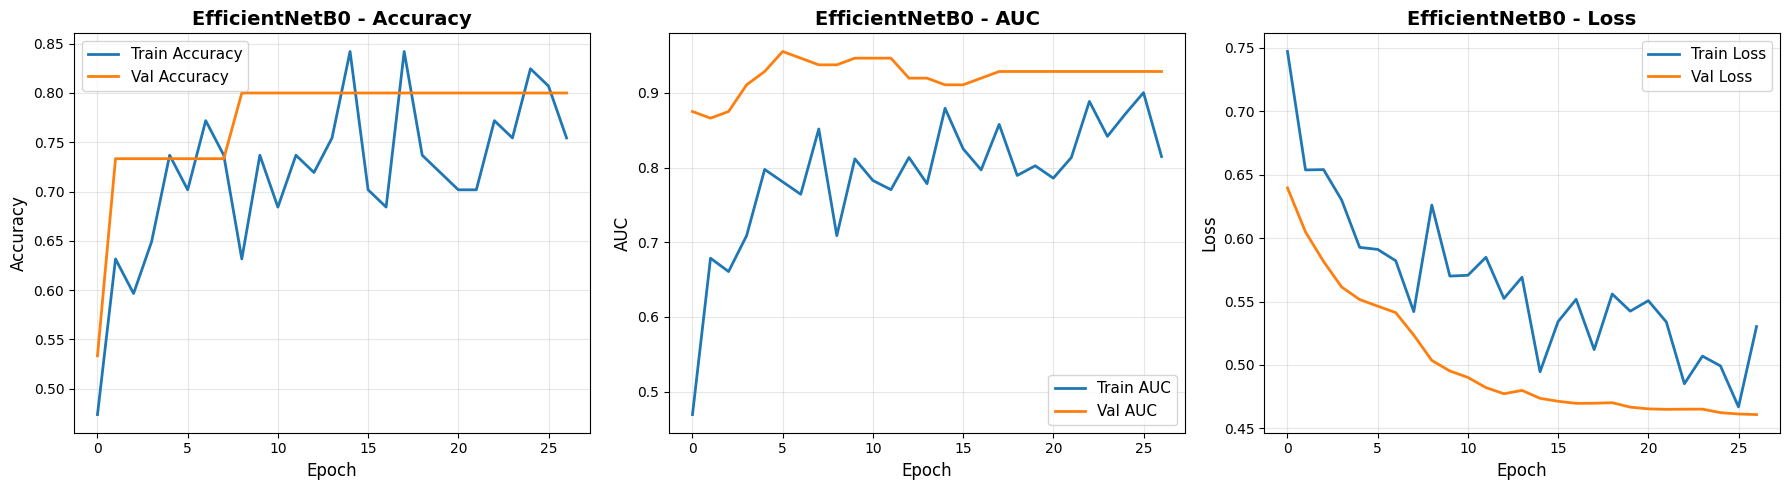

Training history saved: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/EfficientNetB0_training_history.png
Best validation threshold: 0.34
Validation accuracy at best threshold: 0.8667
Validation balanced accuracy at best threshold: 0.8661
Validation F1 at best threshold: 0.8571

CLASSIFICATION REPORT - EfficientNetB0
Threshold used: 0.34
              precision    recall  f1-score   support

     healthy     0.7500    0.8000    0.7742        15
   parkinson     0.7857    0.7333    0.7586        15

    accuracy                         0.7667        30
   macro avg     0.7679    0.7667    0.7664        30
weighted avg     0.7679    0.7667    0.7664        30



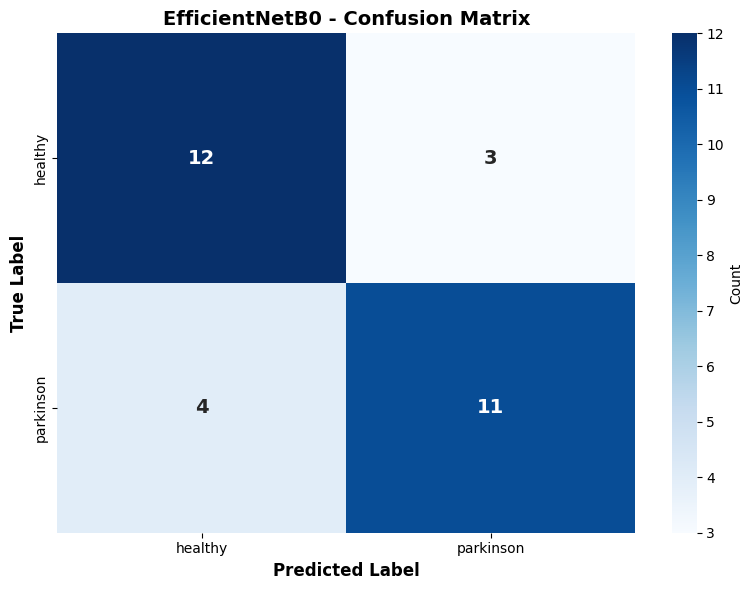

Confusion matrix saved: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/EfficientNetB0_confusion_matrix.png

EFFICIENTNETB0 TRAINING COMPLETE!
  Test Accuracy: 76.67%
  Test AUC: 0.8444
  Threshold: 0.34
  Test Loss: 0.5262


In [ ]:
results = {}

print('\n' + '=' * 60)
print('TRAINING MODEL: EfficientNetB0')
print('=' * 60)

train_generator, val_generator, test_generator = create_generators()

print('  Train batches:', len(train_generator))
print('  Val batches:', len(val_generator))
print('  Test batches:', len(test_generator))
print('  Class indices:', train_generator.class_indices)

model, base_model = create_model()

print('\nPhase 1: train head only')
callbacks_head, checkpoint_head = get_callbacks('head')
history_head = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_head,
    verbose=1
)

if os.path.exists(checkpoint_head):
    model.load_weights(checkpoint_head)
    print(f'Loaded best head checkpoint: {checkpoint_head}')

print('\nPhase 2: fine-tune last layers')
set_trainable_layers(base_model, FINE_TUNE_LAYERS)
compile_model(model, FINE_TUNE_LR)

fine_tune_trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'  Fine-tune trainable params: {fine_tune_trainable:,}')

callbacks_ft, checkpoint_ft = get_callbacks('finetune')
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_ft,
    verbose=1
)

best_checkpoint = checkpoint_ft if os.path.exists(checkpoint_ft) else checkpoint_head
if os.path.exists(best_checkpoint):
    model.load_weights(best_checkpoint)
    print(f'Loaded best checkpoint: {best_checkpoint}')

merged_history = merge_histories(history_head, history_ft)
plot_training_history(merged_history, 'EfficientNetB0')

best_threshold = find_best_threshold(model, val_generator)
eval_results = evaluate_model(model, test_generator, 'EfficientNetB0', threshold=best_threshold)

results['EfficientNetB0'] = {
    'history': merged_history,
    'test_acc': eval_results['test_acc'],
    'test_loss': eval_results['test_loss'],
    'test_auc': eval_results['test_auc'],
    'threshold': eval_results['threshold'],
    'model': model,
    'eval': eval_results,
}

print('\n' + '=' * 60)
print('EFFICIENTNETB0 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['EfficientNetB0']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['EfficientNetB0']['test_auc']:.4f}")
print(f"  Threshold: {results['EfficientNetB0']['threshold']:.2f}")
print(f"  Test Loss: {results['EfficientNetB0']['test_loss']:.4f}")
print('=' * 60)

---
## STEP 5: SAVE ARTIFACTS AND SUMMARY

In [ ]:
best_epoch = int(np.argmin(results['EfficientNetB0']['history'].history['val_loss']) + 1)
epochs_ran = len(results['EfficientNetB0']['history'].history['loss'])

summary_df = pd.DataFrame([
    {
        'model': 'EfficientNetB0',
        'test_accuracy': results['EfficientNetB0']['test_acc'],
        'test_auc': results['EfficientNetB0']['test_auc'],
        'test_loss': results['EfficientNetB0']['test_loss'],
        'threshold': results['EfficientNetB0']['threshold'],
        'best_epoch_by_val_loss': best_epoch,
        'epochs_ran': epochs_ran,
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'head_epochs': HEAD_EPOCHS,
        'fine_tune_epochs': FINE_TUNE_EPOCHS,
        'head_lr': HEAD_LR,
        'fine_tune_lr': FINE_TUNE_LR,
        'fine_tune_layers': FINE_TUNE_LAYERS,
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
    }
])

model_path = os.path.join(SAVE_PATH, 'EfficientNetB0_best.keras')
history_path = os.path.join(SAVE_PATH, 'EfficientNetB0_history.csv')
results_path = os.path.join(SAVE_PATH, 'EfficientNetB0_results.csv')

results['EfficientNetB0']['model'].save(model_path)
pd.DataFrame(results['EfficientNetB0']['history'].history).to_csv(history_path, index=False)
summary_df.to_csv(results_path, index=False)

print('\n' + '=' * 70)
print('EFFICIENTNETB0 RESULTS SUMMARY')
print('=' * 70)
print(f"{'Model':<18} {'Test Accuracy':<15} {'Test AUC':<12} {'Threshold':<10} {'Best Epoch':<10}")
print('-' * 85)
print(f"{'EfficientNetB0':<18} {results['EfficientNetB0']['test_acc'] * 100:>6.2f}%         {results['EfficientNetB0']['test_auc']:<12.4f} {results['EfficientNetB0']['threshold']:<10.2f} {best_epoch:<10}")
print('=' * 70)

print('Saved model to:', model_path)
print('Saved history to:', history_path)
print('Saved summary to:', results_path)


EFFICIENTNETB0 RESULTS SUMMARY
Model              Test Accuracy   Test AUC     Threshold  Best Epoch
-------------------------------------------------------------------------------------
EfficientNetB0      76.67%         0.8444       0.34       27        
Saved model to: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/EfficientNetB0_best.keras
Saved history to: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/EfficientNetB0_history.csv
Saved summary to: /content/drive/MyDrive/Parkinson_Models_EfficientNetB0/EfficientNetB0_results.csv
